In [1]:
using Random, JuMP, Ipopt, LinearAlgebra, SparseArrays
using DifferentialEquations, Sundials
using Plots, LaTeXStrings, Statistics, Measures

# Reproducible statistics over multiple randomly generated Lasso instances.
Random.seed!(2)
gr()

# Problem size and Lasso parameters
n = 20
m = 10
tau = 1.0
rho = 0.1

# Number of randomly generated Lasso examples used for the statistical plot
num_examples = 10

# Number of time samples for each trajectory. Increase to 10000 if you want
# the same resolution as the single-example figure.
num_time_points = 3000

# Avoid log(0) in log-scale plots after finite-time convergence.
err_floor = 1e-7


1.0e-7

In [2]:
function build_lasso_qp(n, m, tau, rho)
    # Generate one random Lasso instance:
    #     min_x ||A*x - b||_2^2 + tau*||x||_1 + rho*||x||_2^2.
    A = 20.0 * rand(m, n) .- 10.0
    b = 20.0 * rand(m) .- 10.0

    Q = [A' * A + rho * Diagonal(ones(n))  -A' * A;
        -A' * A                           A' * A + rho * Diagonal(ones(n))]
    q = [A' * b .+ tau * ones(n);
        -A' * b .+ tau * ones(n)]
    return A, b, Matrix(Q), q
end

function solve_lasso_by_ipopt(Q, q, n)
    # Solve the nonnegative QP reformulation with x = x_plus - x_minus,
    # where x_plus >= 0 and x_minus >= 0.
    Prob = Model(Ipopt.Optimizer)
    set_silent(Prob)
    @variable(Prob, x[1:2*n] >= 0)
    @objective(Prob, Min, 0.5 * x' * Q * x + q' * x)
    optimize!(Prob)

    status = termination_status(Prob)
    if !(status in [MOI.OPTIMAL, MOI.LOCALLY_SOLVED, MOI.ALMOST_OPTIMAL, MOI.ALMOST_LOCALLY_SOLVED])
        @warn "Ipopt did not report an optimal status" status
    end

    x_opt = value.(x[1:n]) - value.(x[n+1:2*n])
    return x_opt
end


function Homogeneous_ode!(residual, dz, z, p, t)
    Q, q, n, k = p
    x = z[1:2*n]
    s = z[2*n+1:4*n]
    temp = [Q*x + q - s;
            x .* s]
    norm_temp = norm(temp) + 1e-8
    M = [Q -Diagonal(ones(2*n));
         Diagonal(s) Diagonal(x)]
    dzdt = -k * (1.0/norm_temp + norm_temp) * temp
    residual .= M * dz - dzdt
end

function run_one_trajectory(Q, q, x_opt, n; Tp=1.0, z0_scale=0.1, num_time_points=3000, err_floor=1e-7)
    # k is selected according to the prescribed convergence time T_p.
    k = 2*pi/(4.0*Tp)
    Tmax = Tp

    z0 = z0_scale * ones(4*n)
    dz0 = zeros(4*n)
    tspan = (0.0, Tmax)
    differential_vars = trues(4*n)

    prob = DAEProblem(
        Homogeneous_ode!, dz0, z0, tspan, (Q, q, n, k),
        differential_vars=differential_vars
    )
    t_points = range(tspan[1], tspan[2], length=num_time_points)
    sol = solve(prob, DFBDF(), saveat=t_points, reltol=1e-7, abstol=1e-8)

    z_traj = sol[1:2*n, :]
    x_traj = z_traj[1:n, :] - z_traj[n+1:2*n, :]

    rel_err = zeros(size(x_traj, 2))
    for i in 1:size(x_traj, 2)
        rel_err[i] = max(norm(x_traj[:, i] - x_opt), err_floor)
    end

    return Array(sol.t), rel_err
end

function summarize_errors(error_list; err_floor=1e-7, q_low=5.0, q_high=95.0)
    # Robust summary for finite-time convergence curves.
    # error_list is a Vector of equal-length error trajectories.
    # The main curve is the median, and the shaded band is the
    # interquartile range [q_low%, q_high%]. This avoids overly large
    # error bands caused by a few trajectories converging slightly earlier
    # or later on a log-scale plot.
    E = reduce(hcat, error_list)'  # size: num_examples x num_time_points

    err_median = vec(median(E, dims=1))
    err_low = [quantile(view(E, :, k), q_low/100) for k in 1:size(E, 2)]
    err_high = [quantile(view(E, :, k), q_high/100) for k in 1:size(E, 2)]

    err_median = max.(err_median, err_floor)
    err_low = max.(err_low, err_floor)
    err_high = max.(err_high, err_floor)

    # Plots.jl ribbon is given as distance from the central curve.
    ribbon_lower = err_median .- err_low
    ribbon_upper = err_high .- err_median
    return err_median, ribbon_lower, ribbon_upper
end


summarize_errors (generic function with 1 method)

In [3]:
# Experiment (1): different prescribed times T_p.
Tp_list = [1.0, 0.8, 0.6, 0.4, 0.2, 0.1]

# Experiment (2): different initial conditions z^0 = c e.
z0_scales = [1, 2, 3, 4, 5, 6]

# Containers for trajectories from all examples.
err_Tp = Dict(Tp => Vector{Vector{Float64}}() for Tp in Tp_list)
time_Tp = Dict{Float64, Vector{Float64}}()

err_z0 = Dict(c => Vector{Vector{Float64}}() for c in z0_scales)
time_z0 = Dict{Int, Vector{Float64}}()

for example_id in 1:num_examples
    println("Running Lasso example ", example_id, " / ", num_examples)

    # Use a different but reproducible random seed for each Lasso instance.
    Random.seed!(example_id)
    A, b, Q, q = build_lasso_qp(n, m, tau, rho)
    x_opt = solve_lasso_by_ipopt(Q, q, n)

    # Left panel: vary T_p, keep the same initial point z^0 = 0.1e.
    for Tp in Tp_list
        t, e = run_one_trajectory(
            Q, q, x_opt, n;
            Tp=Tp,
            z0_scale=0.1,
            num_time_points=num_time_points,
            err_floor=err_floor
        )
        push!(err_Tp[Tp], e)
        if !haskey(time_Tp, Tp)
            time_Tp[Tp] = t
        end
    end

    # Right panel: vary z^0 = c e, keep T_p = 1.0.
    for c in z0_scales
        t, e = run_one_trajectory(
            Q, q, x_opt, n;
            Tp=1.0,
            z0_scale=Float64(c),
            num_time_points=num_time_points,
            err_floor=err_floor
        )
        push!(err_z0[c], e)
        if !haskey(time_z0, c)
            time_z0[c] = t
        end
    end
end


Running Lasso example 1 / 10

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Running Lasso example 2 / 10
Running Lasso example 3 / 10
Running Lasso example 4 / 10
Running Lasso example 5 / 10
Running Lasso example 6 / 10
Running Lasso example 7 / 10
Running Lasso example 8 / 10
Running Lasso example 9 / 10
Running Lasso example 10 / 10


**Plotting note.** The curves below report the median trajectory over 10 randomly generated Lasso instances. The shaded regions show the interquartile range (5th--95th percentiles), which is more robust than mean $\pm$ standard deviation for finite-time convergence curves on a logarithmic scale.


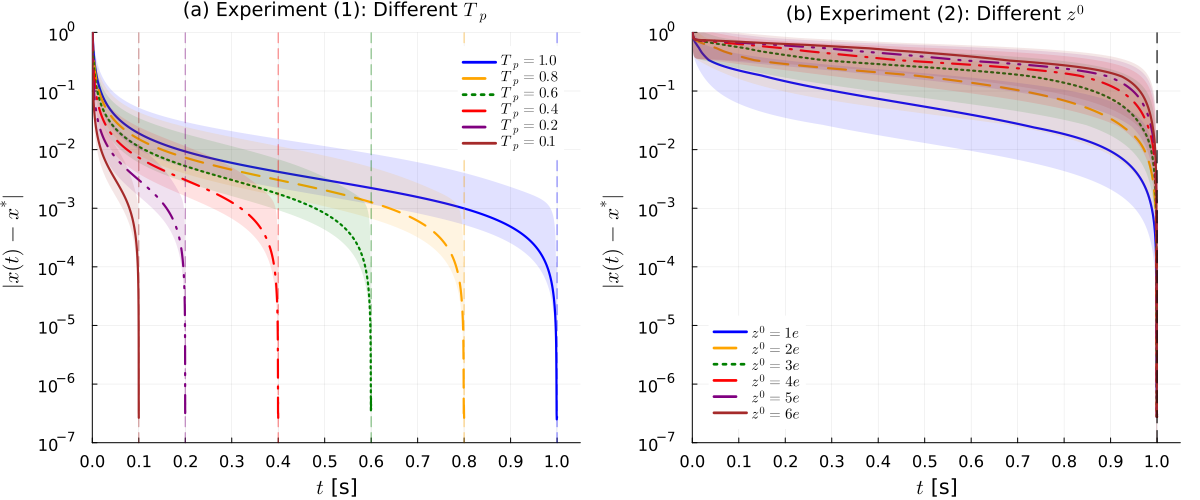

In [4]:
colors = [:blue, :orange, :green, :red, :purple, :brown]
styles = [:solid, :dash, :dot, :dashdot, :dashdotdot, :solid]

common_kwargs = (
    yscale=:log10,
    yticks=[1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
    xticks=0:0.1:1,
    xlabel=L"$t$ [s]",
    ylabel=L"$\|x(t)-x^*\|$",
    grid=true,
    legendfontsize=10,
    guidefontsize=14,
    tickfontsize=11,
    titlefontsize=13,
    foreground_color_legend=nothing,
    background_color_legend=:white,
)

p1 = plot(; common_kwargs...,
    title=L"(a) Experiment (1): Different $T_p$",
    legend=:topright,
    xlims=(0, 1.05),
    ylims=(1e-7, 1),
)

for (j, Tp) in enumerate(Tp_list)
    err_median, ribbon_lower, ribbon_upper = summarize_errors(err_Tp[Tp]; err_floor=err_floor)
    plot!(p1, time_Tp[Tp], err_median,
        ribbon=(ribbon_lower, ribbon_upper),
        fillalpha=0.12,
        fillcolor=colors[j],
        linewidth=2.2,
        linestyle=styles[j],
        color=colors[j],
        label=latexstring("T_p = $(Tp)"),
    )
    vline!(p1, [Tp], linestyle=:dash, color=colors[j], alpha=0.45, linewidth=1.2, label="")
end

p2 = plot(; common_kwargs...,
    title=L"(b) Experiment (2): Different $z^0$",
    legend=:bottomleft,
    xlims=(0, 1.05),
    ylims=(1e-7, 1),
)

for (j, c) in enumerate(z0_scales)
    err_median, ribbon_lower, ribbon_upper = summarize_errors(err_z0[c]; err_floor=err_floor)
    plot!(p2, time_z0[c], err_median,
        ribbon=(ribbon_lower, ribbon_upper),
        fillalpha=0.12,
        fillcolor=colors[j],
        linewidth=2.2,
        linestyle=styles[j],
        color=colors[j],
        label=latexstring("z^0 = $(c)e"),
    )
end
vline!(p2, [1.0], linestyle=:dash, color=:black, alpha=0.75, linewidth=1.5, label="")

fig = plot(
    p1, p2,
    layout=(1, 2),
    size=(1200, 500),
    left_margin=5mm,
    bottom_margin=5mm,
    right_margin=3mm,
    top_margin=3mm,
)

display(fig)


In [5]:
savefig(fig, "Fig1_Lasso_10examples_median_percentile.pdf")


"/Users/liang/Documents/Julia_Projects/Fixed_time_stable_Lasso/Fig1_Lasso_10examples_median_percentile.pdf"